# Chapter 4:  Grover’s Algorithm

This lesson is based on Grover's algorithm. It is a search algorithm for unstructured search problems. [Quantum Algorithm Zoo](https://quantumalgorithmzoo.org/)

COntent:
1. Unstructured search
2. Grover’s Algorithm
    - Algorithm description
    - Analysis
3. Choosing the number of iterations
    - Unique search
    - Multiple Solutions
4. Conclusion
5. Implementation on Qiskit
    - Grover Algorithm
    - Precision depending of the number of solution

## 1. Unstructered search
We set $\Sigma = \left\{ 0,1 \right\}$ which corresponds to the binary alphabet.

We assume that we have a function $f$ that does:

$$
f: \Sigma^n \rightarrow \Sigma
$$

which can be calculated efficiently. 

Our goal is to find a solution that is a binary string $x \in \Sigma^n$ for $f(x)=1$.

<b>Search algorithm</b>:
>Input: $f: \Sigma^n \rightarrow \Sigma$\
>Output: a string $a \in \Sigma^n$ satisfying $f(x)=1$, or no solution if no such string exists. 

This is an unstructured problem because $f$ is arbitrary. There is no promise, and we cannot count on it to obtain a structure that allows us to obtain solutions easily.

We note:

$$
N = 2^n
$$

When a letter is capitalized, it corresponds to the power $2$ of the lowercase letter. 

By iterating over all $x \in \Sigma$ and evaluating $f$ for each one, we can solve the search with $N$ queries. 

This is the best we can do with a deterministic algorithm. 

Probabilistic algorithms offer minimal improvements, but require a number of queries that is linear to $N$.  Grover's algorithm is a search algorithm that requires a number of queries in $O(\sqrt{N})$.

<b>Phase query gates<b/>:

We assume that we have access to a function $f: \Sigma^n \rightarrow \Sigma$ through a query gate.

$$
U_f:|a\rangle|x\rangle \rightarrow |a\oplus f(x)\rangle|x\rangle \space\space (\forall x \in \Sigma \text{ and } x \in \Sigma^n )
$$

We can construct a circuit $U_f$ for a Boolean circuit for $f$.

A “phase query gate” or phase query gate for $f$ operates as follows:

$$
Z_f:|x\rangle \rightarrow (-1)^{f(x)}|x\rangle \space (\forall x \in \Sigma^n)
$$

Circuit example:

<div align="center">
    <img src="./Images/4_1_example_phase_query_gate.png" alt="4_1_example_phase_query_gate" width="600"/>
</div>

With a control qubit, it is possible to reconvert $U_f$, otherwise not.
Need for a phase query gate for n-bit OR function:

$$
(\forall x \in \Sigma^n ) \space \space OR(x) = \begin{equation}
    \left\{ 
        \begin{array}{cc}
                0 & x=0^n \\ 1 & x \ne 0^n          
        \end{array}
    \right .
\end{equation} $$
$$(\forall x \in \Sigma^n ) \space \space ZOR(x) = \begin{equation}
    \left\{ 
        \begin{array}{cc}
                |x> & x=0^n \\ -|x> & x \ne 0^n 
        \end{array}
    \right .
\end{equation} 
$$


## 2. Grover’s Algorithm
Algorithm:
>1. <u>Initialize</u>: Set $n$ qubits in the state $H^{\otimes n}|0^n>$
>2. <u>Iteration</u>: Apply Grover's operation $t$ times ($t$ is specialized later)
>3. <u>Measurement</u>: A standard measurement basis provides a candidate solution. 

Grover's operator is defined as follows: 

$$
G = H^{\otimes n }Z_{OR}H^{\otimes n }Z_{f}
$$

$Z_f$  is the query phase gate for f and $Z_{OR}$ is the query phase gate for the $n$-bit $OR$ function.

<div align="center">
    <img src="./Images/4_2_Grover_operator.png" alt="4_2_Grover_operator" width="600"/>
</div>


A typical Grover algorithm can be applied as follows:
>1. Choose a number of iterations $t$
>2. Run Grover's algorithm with $t$ iterations to obtain a candidate solution $x$. 
>3. Check the solution. If $f(x)=1$, then output $x$; otherwise, run Grover's algorithm again (if available with a different $t$); otherwise, there are no solutions.

Solutions and non-solutions:\
We refer to Grover's algorithm for $n$ qubits as a $Q$ register.

We are interested in what happens when $Q$ is initialized in the state $H^{\otimes n}|0^n\rangle$ and Grover's operator $G$ is used iteratively. 

$$
G = H^{\otimes n }Z_{OR}H^{\otimes n }Z_{f}
$$

The sets of non-solutions and solutions are:
>$$
A_0 = \left\{x \in \Sigma^n: f(x)=0 \right\}$$
>$$A_1 = \left\{x \in \Sigma^n: f(x)=1 \right\}
$$

$A_0$  contains all non-solutions and $A_1$ contains all solutions.

We may be interested in the set of superpositions of these sets:
>$$
|A_0\rangle = \frac{1}{\sqrt{|A_0|}} \sum_{x\in A_0}|x\rangle $$
>$$|A_1\rangle = \frac{1}{\sqrt{|A_1|}} \sum_{x\in A_1}|x\rangle \\
$$

Of course, we assume that these sets are not empty. 

<b>Analysis</b>:

The $Q$ register is initially initialized:

$$
|u\rangle = H^{\otimes n }|0^n\rangle \space=\frac{1}{\sqrt{N}}\sum_{x \in \Sigma^n} |x\rangle
$$

This state is contained in the extended subspace of $|A_0\rangle$ and $|A_1\rangle$:

$$
|u\rangle = \sqrt{\frac{|A_0|}{N}}|A_0\rangle+\sqrt{\frac{|A_1|}{N}}|A_1\rangle
$$

The state of $Q$ remains in the subspace after each application of the Grover operator $G$.

Action of the Grover operation:

$$
G = (H^{\otimes n }Z_{OR}H^{\otimes n })(Z_{f})
$$


1. Reminder:
>$$Z_f:|x\rangle \rightarrow (-1)^{f(x)}|x\rangle \space (\forall x \in \Sigma^n)$$
>The actions of $Z_f$ on $|A_1\rangle$ and $|A_0\rangle$ are:
>$$Z_f|A_0\rangle =  |A_0\rangle $$
$$Z_f|A_1\rangle =  -|A_1\rangle $$


2. The operation $Z_{OR}$ is defined as follows:
>$$ZOR(x) = \begin{equation}
    \left\{ 
        \begin{array}{cc}
                |x\rangle & x=0^n \\ -|x\rangle & x \ne 0^n 
        \end{array}
    \right .
\end{equation} 
$$
>There is an alternative notation for $Z_f$:
>$$Z_{OR} = 2|0^n\rangle\langle0^n|-\mathbb{I}$$
>Using this expression, we can rewrite $H^{\otimes n }Z_{OR}H^{\otimes n }$ as:
>$$H^{\otimes n }Z_{OR}H^{\otimes n } = H^{\otimes n }(2|0^n\rangle\langle0^n|-\mathbb{I})H^{\otimes n } = 2|u\rangle\langle u|-\mathbb{I}$$


Then: 
$$
G|A_0\rangle = (2|u\rangle\langle u|-\mathbb{I}) Z_f|A_0\rangle $$
$$=(2|u\rangle\langle u|-\mathbb{I})|A_0\rangle $$
$$= 2\sqrt{\frac{|A_0|}{N}}|u\rangle-|A_0\rangle $$
$$= 2\sqrt{\frac{|A_0|}{N}}(\sqrt{\frac{|A_0|}{N}} |A_0\rangle+\sqrt{\frac{|A_1|}{N}}|A_1\rangle) - |A_0\rangle $$
$$= \frac{\sqrt{|A_0|-|A_1|}}{N}|A_0\rangle +2\frac{\sqrt{|A_0|.|A_1|}}{N}|A_1\rangle
$$

Finally:

$$
G|A_0\rangle = \frac{{|A_0|-|A_1|}}{N}|A_0\rangle +2\frac{\sqrt{|A_0|.|A_1|}}{N}|A_1\rangle 
$$

Similarly, for $G|A_1\rangle$, we obtain:

$$
G|A_1\rangle = -2\frac{\sqrt{|A_0|.|A_1|}}{N}|A_0\rangle +\frac{{|A_0|-|A_1|}}{N}|A_1\rangle
$$

The action of G on the set $\left\{ |A_0\rangle, |A_1\rangle \right\}$ can be described as a square matrix of dimension $2$:

$$
M = \begin{pmatrix} \frac{{|A_0|-|A_1|}}{N} & -2\frac{\sqrt{|A_0|.|A_1|}} {N}  \\ 2\frac{\sqrt{|A_0|.|A_1|}}{N} & \frac{{|A_0|-|A_1|}}{N} \end {pmatrix}  = \begin{pmatrix} \sqrt\frac{{|A_0|}}{N} & -\sqrt\frac{{|A_1|}}{N}  \\ \sqrt\frac{{|A_1|}}{N} & \sqrt\frac{{|A_0|}}{N} \end{pmatrix}^2
$$

We can observe a rotation matrix for a fixed angle. 

$$
\begin{pmatrix} \sqrt\frac{{|A_0|}}{N} & -\sqrt\frac{{|A_1|}}{N}  \\ \sqrt\frac{{|A_1|}}{N} & \sqrt\frac{{|A_0|}}{N} \end{pmatrix} = \begin{pmatrix} cos(\theta) & -sin(\theta) \\ sin(\theta) & cos(\theta) \end{pmatrix} $$
$$\theta = sin^{-1}(\sqrt\frac{{|A_1|}}{N})
$$

By applying the square, we observe in this case that $M$ is a rotation matrix of $2\theta$:

$$
M = \begin{pmatrix} cos(2\theta) & -sin(2\theta)  \\ sin(2\theta) & cos(2\theta) \end{pmatrix} $$

After initializing the step, this corresponds to the register of $Q$:

$$
|u\rangle = \sqrt{\frac{|A_0|}{N}}|A_0\rangle+\sqrt{\frac{|A_1|}{N}}|A_1\rangle = cos(\theta)|A_0\rangle+sin(\theta)|A_1\rangle
$$

Each time the Grover operator is applied, the $Q$ state is rotated by an angle $2\theta$:
$$|u\rangle = cos(\theta)|A_0\rangle+sin(\theta)|A_1\rangle $$
$$G|u\rangle = cos(3\theta)|A_0\rangle+sin(3\theta)|A_1\rangle $$
$$G^2|u\rangle = cos(5\theta)|A_0\rangle+sin(5\theta)|A_1\rangle $$
$$... $$
$$ G^t|u\rangle = cos((2t+1)\theta)|A_0\rangle+sin((2t+1)\theta)|A_1\rangle $$

<b>Geometric figure</b>:

Main idea:\
The operator $G = H^{\otimes n }Z_{OR}H^{\otimes n }Z_f$ is composed of two reflections:

$$
Z_f \text{   and   } \space H^{\otimes n }Z_{OR}H^{\otimes n }
$$

Composing two reflections leads to a rotation.

1. Reminder of the action of $Z_f$:
$$Z_f|A_0\rangle = |A_0\rangle $$
$$Z_f|A_1\rangle = -|A_1\rangle$$

<div align="center">
    <img src="./Images/4_3_geometric_operation_Zf.png" alt="4_3_geometric_operation_Zf" width="600"/>
</div>

This corresponds to a reflection of $|\psi\rangle$ with respect to the line $L_1$ parallel to $|A_0\rangle$.

2. The operation $H^{\otimes n }Z_{OR}H^{\otimes n }$ can be expressed as follows:

$$
H^{\otimes n }Z_{OR}H^{\otimes n } = 2|u\rangle\langle u|-\mathbb{I}
$$

This corresponds to a reflection with respect to $L_2$ parallel to $|u\rangle$.
<div align="center">
    <img src="./Images/4_4_geometric_operation_Grover_op.png" alt="4_4_geometric_operation_Grover_op" width="600"/>
</div>

3. When two reflections are combined, the result is a rotation of twice the angle between the two lines ($L_1 \text{ and } L_2$).

<div align="center">
    <img src="./Images/4_5_geometric_operation_Grover_algo.png" alt="4_5_geometric_operation_Grover_algo" width="600"/>
</div>

Target settings:

Consider a quantum state of the form:

$$
\alpha |A_1\rangle + \beta |A_0\rangle
$$

The measurements lead to a solution $x \in A_1$ with a probability $|\beta|^2$.

$$
\alpha |A_1\rangle + \beta |A_0\rangle = \frac{\alpha}{\sqrt{|A_0|}}\sum_{x\in A_0}|x\rangle+\frac{\beta}{\sqrt{|A_1|}}\sum_{x\in A_1}|x\rangle
$$

The output probabilities:

$$
p(x) = \begin{equation}
    \left\{ 
        \begin{array}{cc}
                \frac{|\alpha|^2}{|A_0|} & x\in A_0 \\ \frac{|\beta|^2}{|A_1|} & x\in A_1 
        \end{array}
    \right .
\end{equation}
$$

$$
P_r(A_1) = \sum_{x\in A_1}p(x)=|\beta|^2
$$

What is the $Q$ operator when Grover's algorithm is applied $t$ times? 

$$
G^t|u\rangle = cos((2t+1)\theta)|A_0\rangle+sin((2t+1)\theta)|A_1\rangle, \space \theta = sin^{-1}(\sqrt\frac{{|A_1|}}{N})
$$

The probability of measuring the output $x \in A_1$ after $t$ iterations is:

$$
sin^2((2t+1)\theta)
$$

We want to maximize the probability, so we say that $|A_1\rangle$ is our target state.

To maximize the probability close to $1$ and maximize $t$, we set the parameters as follows:

$$
(2t+1)\theta \approx \frac{\pi}{2} \Leftrightarrow t \approx \frac{\pi}{4\theta}-\frac{1}{2} \rightarrow t = \left\lfloor  \frac{\pi}{4\theta}\right\rfloor
$$

Important considerations:

- $t$ must be an integer.
- $\theta$  depends on the number of solutions.




## 3. Choosing the number of iterations

<b>Unique search</b>:
>Input: $f: \Sigma^n \rightarrow \Sigma$\
>Promise: There is a unique solution $z \in \Sigma^n$ for which $f(z)=1$, and for which $f(z)=0$ for all other $x \neq z$.\
>Output: The string $z$.

For a unique search, we have $s = |A_1|=1$, and therefore:

$$
\theta = sin^{-1}(\sqrt{\frac{1}{N}}) \approx \sqrt{\frac{1}{N}}
$$

Substituting $\theta \approx 1/\sqrt{N}$ into the expression for t, we obtain:

$$
t = \left\lfloor  \frac{\pi}{4}\sqrt{N}\right\rfloor
$$

We have a number of queries with complexity $O(\sqrt{N})$.

A measurement after $t$ iterations gives a unique solution for $x \in A_1$ with a probability of:
$$p(N,1) = sin^2((2t+1)\theta)$$

It can be proven analytically that:

$$
p(N,1) \geq 1-\frac{1}{N}
$$

<div align="center">
    <img src="./Images/4_6_table_probability_success_unique_search.png" alt="4_6_table_probability_success_unique_search" width="400"/>
</div>


<b>Multiple solutions</b>:
>Input: $f: \Sigma^n \rightarrow \Sigma$\
>Promise: There is a multiple solution $z \in \Sigma^n$ for which $f(z)=s$, and for which $f(z)=0$ for all other $x \neq z$.\
>Output: The string $z$.


$$
s = 4 \rightarrow \theta=sin^{-1}(\sqrt\frac{s}{N})
$$

For each $s \in \left\{ 1,...,N \right\}$ the measurement probability $p(N,s)$ of finding a solution satisfies:

$$
p(N,s) \geq max\left\{ 1-\frac{s}{N},\frac{s}{N}\right\}
$$

Number of queries:

$$
\theta=sin^{-1}(\sqrt\frac{s}{N}) , \space \space t = \left\lfloor  \frac{\pi}{4\theta} \right\rfloor
$$

Each iteration of Grover's algorithm requires $1$ query to evaluate $f$. How many queries $t$ depend on $N$ and $s$?

$$
sin^{-1} \geq x, \space \forall x\in \left[ 0,1\right] \\ \theta=sin^{-1}(\sqrt\frac{s}{N}) \geq \sqrt\frac{s}{N}\\ t \leq \frac{\pi}{4\theta} \leq \frac{\pi}{4}\sqrt\frac{N}{s} \\ t=O( \sqrt\frac{N}{s})
$$

<u>What happens when we don't know the number of solutions in advance </u>?

Simple approach:

Choose a number of iterations $t \in \left\{ 1,..., \left\lfloor  {\pi\sqrt{N}}/{4} \right\rfloor \right\}$ in a uniform random manner.

- The probability of finding a solution (if it exists) is at least $40$%. (Repeat the process several times to increase the probability).
- The number of queries or evaluations of $f$ is of complexity $O(\sqrt{N})$

More sophisticated approach:
>1. Let $T=1$
>2. Run Grover's algorithm with $t \in \left\{ 1,...,T \right\}$ chosen uniformly at random.
>3. If a solution is found, stop and output the value of $T$.\
>   
>Otherwise, increase $T$ and return to step 2 (or report that there is no solution).
    

- The rate increases with $T$ must be correctly balanced: a low rate requires more queries, a high rate decreases the probability of success. $T \leftarrow \left\lceil  \frac{5}{4}T\right\rceil$ works.
- If the number of solutions $s\geq 1$, then the number of queries $f$ requires $O(\sqrt{N/s})$. If there is no solution, then $O(\sqrt{N})$ queries are required.


## 4. Conclusion

- Grover's algorithm is asymptotically optimal
- Grover's algorithm is widely applicable
- The technique of Grover's algorithm can be generalized

## 5. Implementation on Qiskit
### Grover Algorithm

In [1]:
import math
from qiskit import QuantumCircuit
from qiskit.circuit.library import MCMTGate, ZGate, grover_operator
from qiskit.visualization import plot_distribution

from qiskit_ibm_runtime.fake_provider import FakeBrisbane
from qiskit_ibm_runtime import SamplerV2 as Sampler

In [2]:
backend = FakeBrisbane()

In [3]:
def grover_oracle(marked_states):
    """Build a Grover oracle for multiple marked states

    Here we assume all input marked states have the same number of bits

    Parameters:
        marked_states (str or list): Marked states of oracle

    Returns:
        QuantumCircuit: Quantum circuit representing grover oracle
    """
    if not isinstance(marked_states, list):
        marked_states = [marked_states]
    #compute the number of qubits in circuit
    num_qubits = len(marked_states[0])

    qc = QuantumCircuit(num_qubits)
    # mark each target state in the input list
    for target in marked_states:
        # Flip target bit-string to match Qiski bit-ordering
        rev_Target = target[::-1]
        # Find the indices of all the '0' elements in bit string
        zero_inds = [ind for ind in range(num_qubits) if rev_Target.startswith("0",ind)]
        #add a multi-controlled Z-Gate with pre- and post-applied X-Gates (open-controls)
        #where the target bit-string has a '0' entry
        qc.x(zero_inds)
        qc.compose(MCMTGate(ZGate(), num_qubits-1,1), inplace=True)
        qc.x(zero_inds)
    return qc

### specific instance
Here we define the value to search. In this example, $s=2$ the number of solution

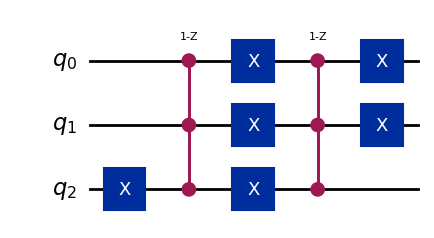

In [4]:
marked_states = ["011", "100"]

oracle = grover_oracle(marked_states)
oracle.draw("mpl")

### GroverOperator

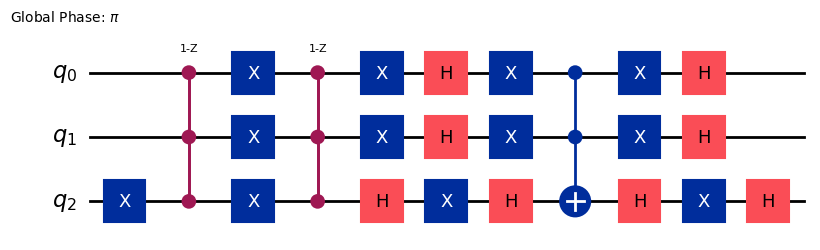

In [5]:
grover_op = grover_operator(oracle)
grover_op.draw("mpl", style = 'iqp')

In [6]:
optimal_num_iterations = math.floor(math.pi/(4*math.asin(math.sqrt(len(marked_states)/2**grover_op.num_qubits))))
print(optimal_num_iterations)

1


### Full Grover circuit
#### Step 1: Mapping the problem

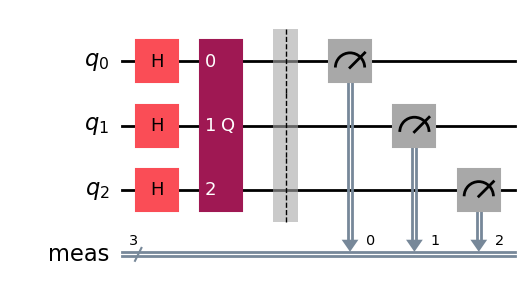

In [7]:
qc = QuantumCircuit(grover_op.num_qubits)
# create even superposition of all basis states
qc.h(range(grover_op.num_qubits))
#apply grover operator the optimal number of times
qc.compose(grover_op.power(optimal_num_iterations), inplace = True)
qc.measure_all()
qc.draw("mpl")

#### Step 2: optimize the circuit

(CVXPY) Aug 03 05:29:47 PM: Encountered unexpected exception importing solver GLOP:
RuntimeError('Unrecognized new version of ortools (9.14.6206). Expected < 9.12.0. Please open a feature request on cvxpy to enable support for this version.')
(CVXPY) Aug 03 05:29:47 PM: Encountered unexpected exception importing solver PDLP:
RuntimeError('Unrecognized new version of ortools (9.14.6206). Expected < 9.12.0. Please open a feature request on cvxpy to enable support for this version.')


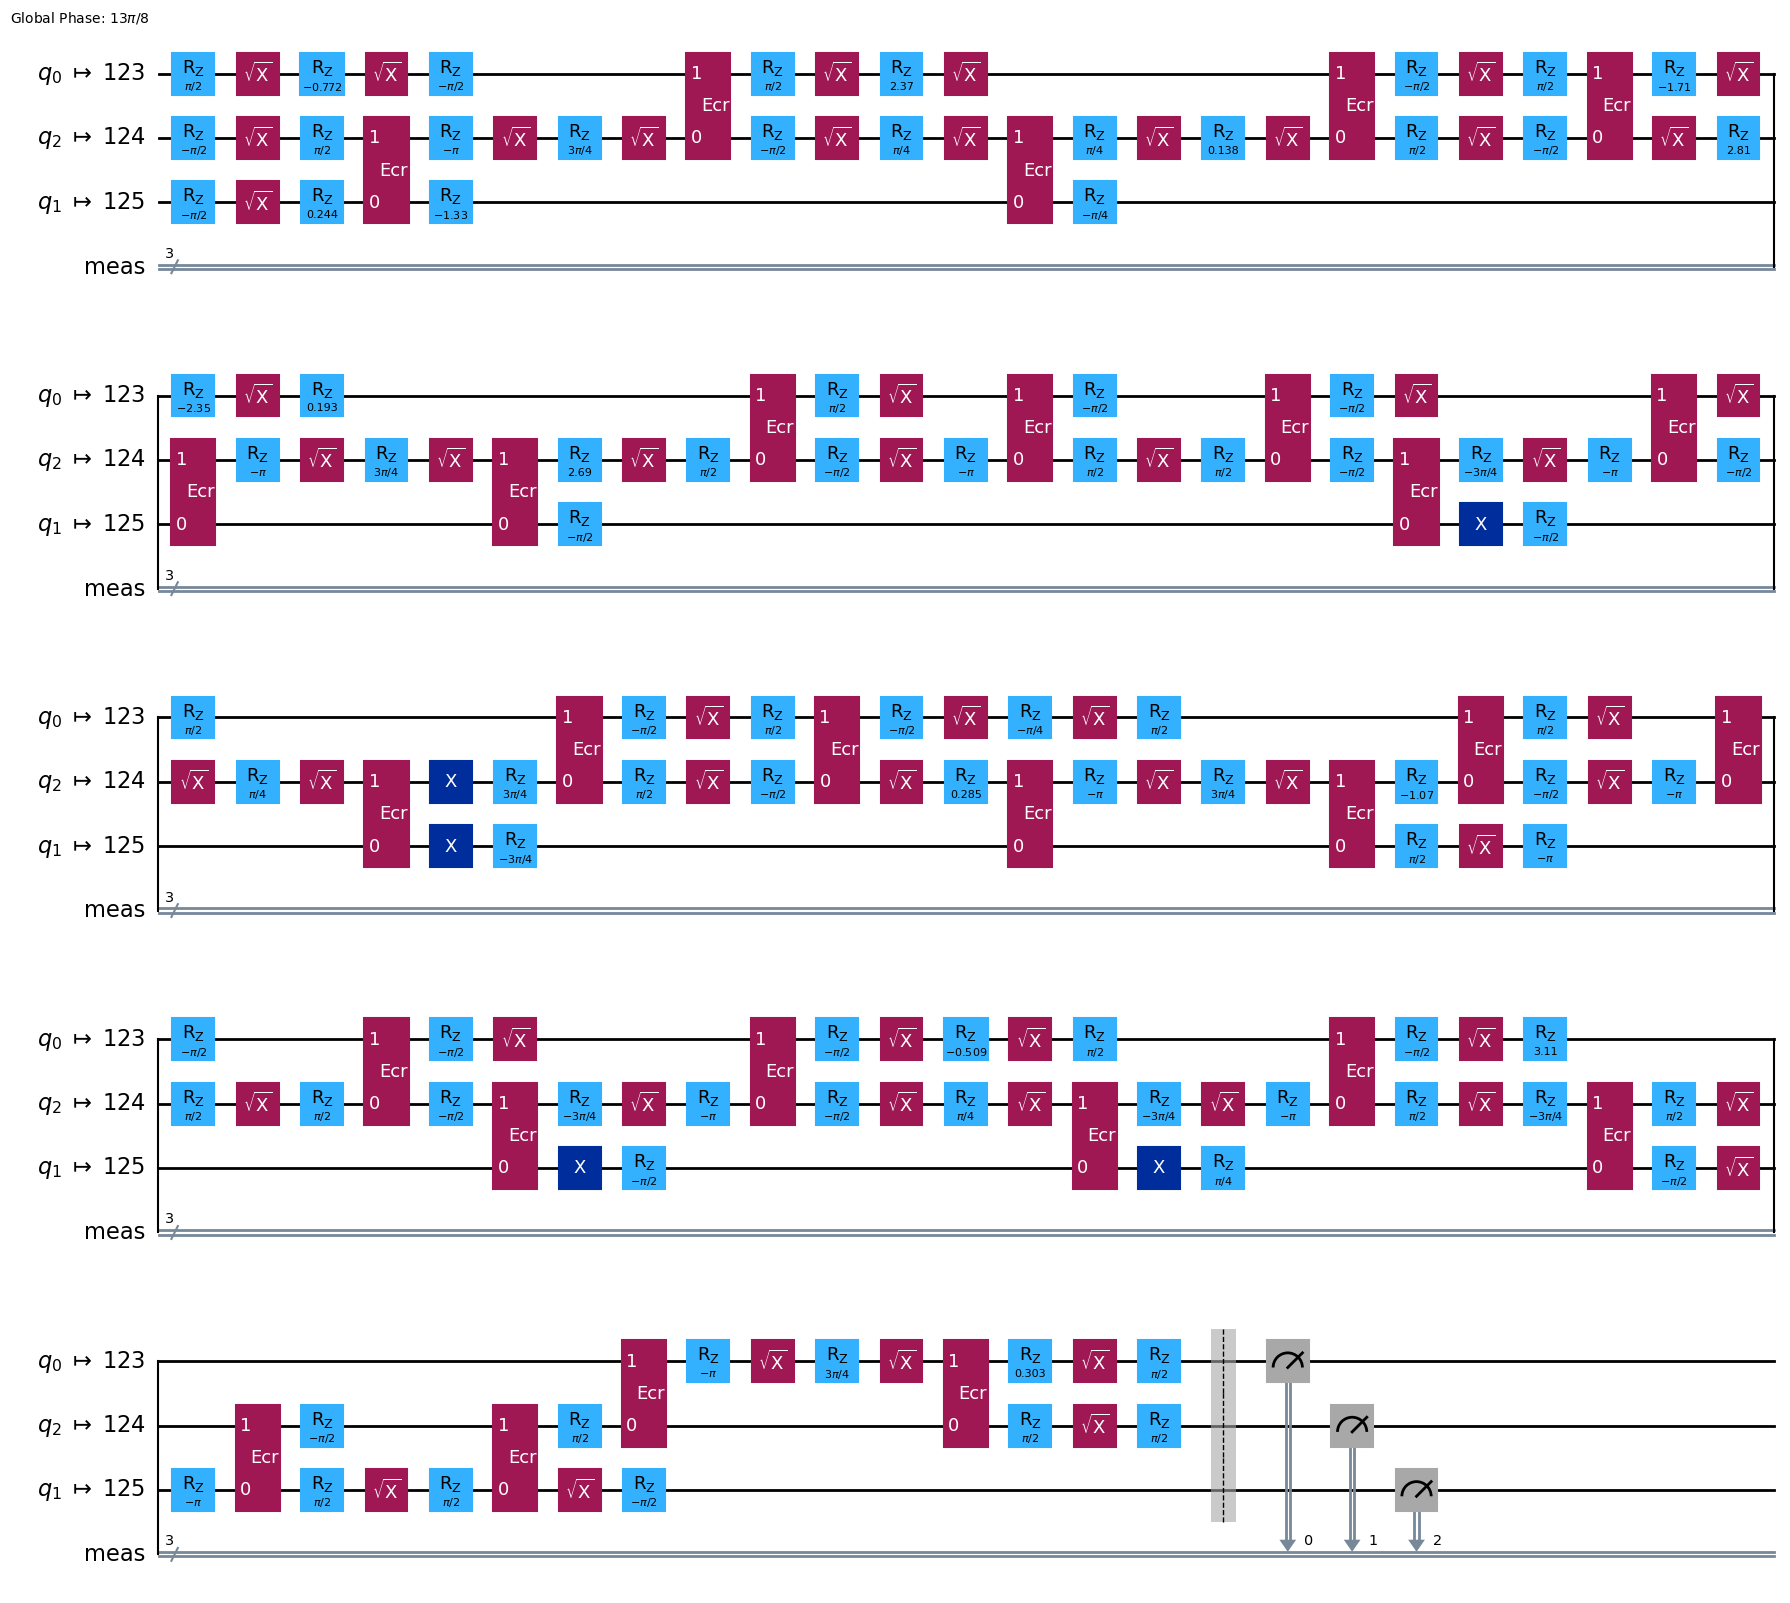

In [8]:
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)

circuit_isa = pm.run(qc)
circuit_isa.draw("mpl", idle_wires =False)

#### Step 3: execute using qiskit primitives

In [9]:
sampler = Sampler(mode=backend)
sampler.options.default_shots = 10000
result = sampler.run([circuit_isa]).result()
dist = result[0].data.meas.get_counts()

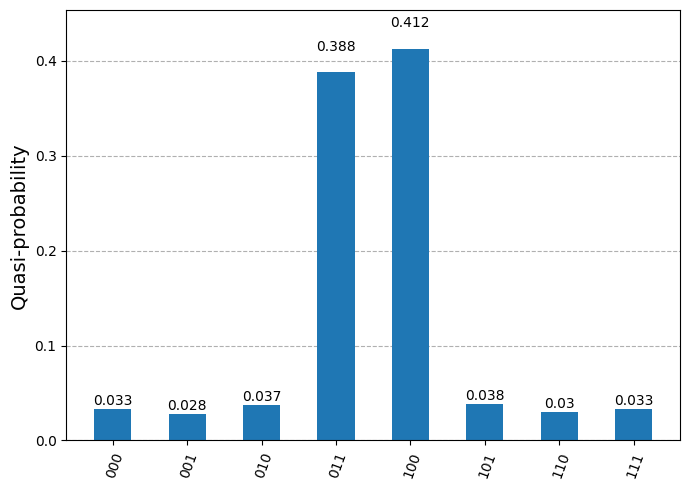

In [10]:
dist = result[0].data.meas.get_counts()
plot_distribution(dist)

#### Step 4: post processing
Here we can see the two maximum probability correspond to the two searched value.

### Precision of the Grover algorithm depending of the number of solutions
#### Single Output

In [11]:
import numpy as np
import math
import matplotlib.pyplot as plt

Scatter Plot


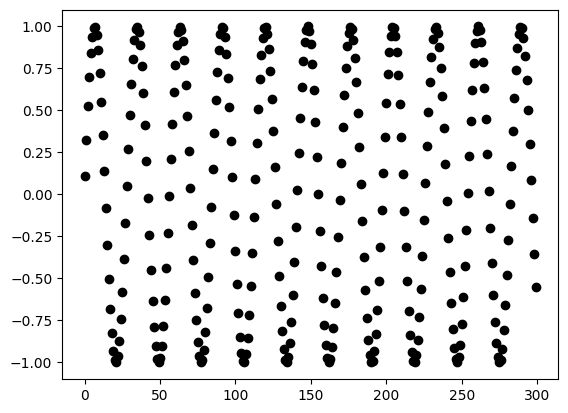

Linear interpolation


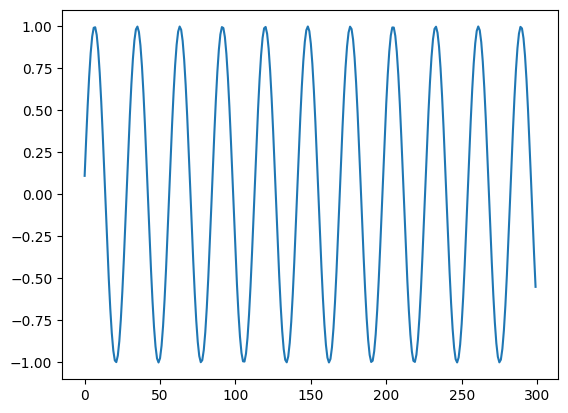

In [12]:
theta = 1/9 # the angle theta
t = np.arange(0,300,1) # number of iterations
y = np.sin((2*t+1)*theta)

print("Scatter Plot")
plt.plot(t,y,'o', color='black')
plt.show()

print("Linear interpolation")
plt.plot(t,y)
plt.show()

2	 0.5000000000
4	 1.0000000000
8	 0.9453125000
16	 0.9613189697
32	 0.9991823155
64	 0.9965856808
128	 0.9956198657
256	 0.9999470421
512	 0.9994480262
1024	 0.9994612447
2048	 0.9999968478
4096	 0.9999453461
8192	 0.9999157752
16384	 0.9999997811
32768	 0.9999868295
65536	 0.9999882596
131072	 0.9999992587
262144	 0.9999978382
524288	 0.9999997279


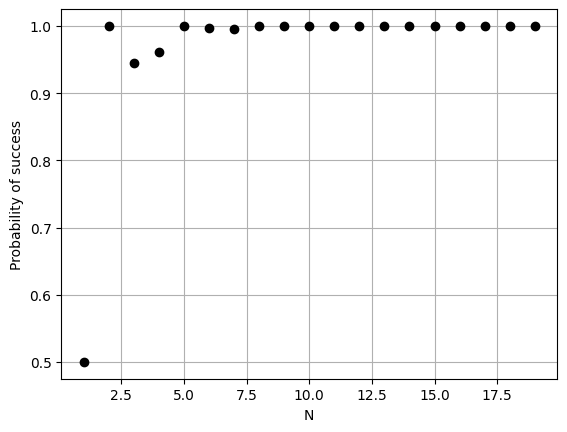

In [13]:
# Probability of success of Grover Algo for N in range from 0 to 2**20, for theta = 1/9
for n in range(1,20):
    N = 2**n
    theta = np.arcsin(np.sqrt(1/N))
    t = math.floor(np.pi/(4*theta))
    p = np.sin((2*t+1)*theta)**2
    print("%d\t %12.10f" % (N, p))
    plt.plot(n,p, 'o', color='black')
plt.grid()
plt.xlabel("N")
plt.ylabel("Probability of success")
plt.show()

#### Multiple Output

4	 1.0000000000
8	 0.5000000000
16	 0.2500000000
32	 0.0122070313
64	 0.0203807689
128	 0.0144530758
256	 0.0000705058
512	 0.0019310741
1024	 0.0023009083
2048	 0.0000077506
4096	 0.0002301502
8192	 0.0003439882
16384	 0.0000007053
32768	 0.0000533810
65536	 0.0000472907
131072	 0.0000030066
262144	 0.0000086824
524288	 0.0000010820


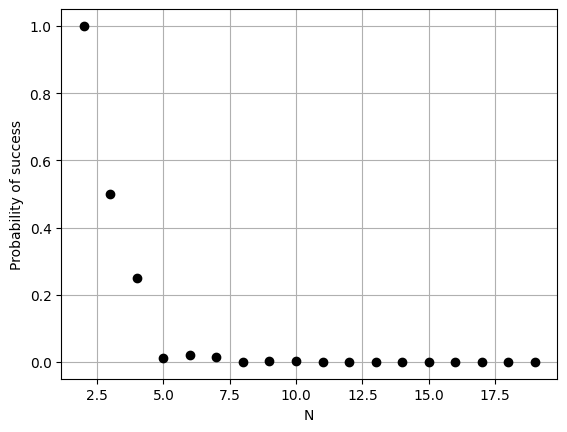

In [14]:
# Starting the loop with n=2 because we can't have 4 solutions
# when n=1.

for n in range(2,20):
    N = 2**n
    wrong_theta = np.arcsin(np.sqrt((1/N)))
    correct_theta = np.arcsin(np.sqrt(4/N))
    t = math.floor(np.pi/(4*wrong_theta))
    p = np.sin((2*t+1)*correct_theta)**2

    print("%d\t %12.10f" % (N, p))
    plt.plot(n,p, 'o', color='black')
plt.grid()
plt.xlabel("N")
plt.ylabel("Probability of success")
plt.show()

Here  we can see that the probability of sucess decrease, beacause the initilisaitlization of $\theta$ is wrong. Then when we increase the number of iterations we get the wrong probability of success. 

8	 0.8750000000
16	 0.6835937500
32	 0.9877929688
64	 0.9869401455
128	 0.9933758959
256	 0.9942813445
512	 0.9977678832
1024	 0.9999963373
2048	 0.9999257666
4096	 0.9983374778
8192	 0.9995465664
16384	 0.9995822234
32768	 0.9999531497
65536	 0.9998961946
131072	 0.9999998224
262144	 0.9999745784
524288	 0.9999894829
1048576	 0.9999939313
2097152	 0.9999979874
4194304	 0.9999986243


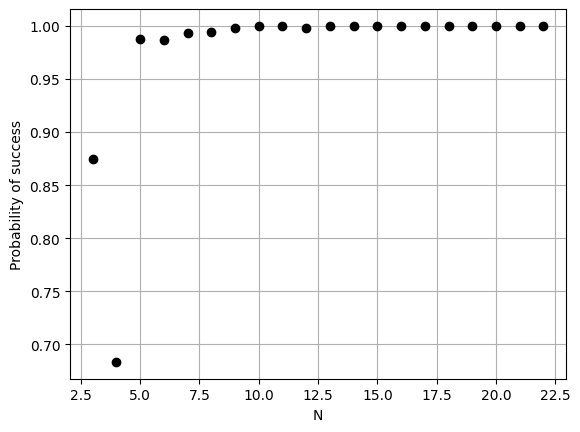

In [15]:
s = 7 # number of solutions

# the loop starts with the smallest value of n that allows s solutions

for n in range(math.ceil(math.log2(s)), math.ceil(math.log2(s)+20)):
    N = 2**n
    theta = np.arcsin(np.sqrt(s/N))
    t = math.floor(np.pi/(4*theta))
    p = np.sin((2*t+1)*theta)**2
    print("%d\t %12.10f" % (N, np.sin((2 * t + 1) * theta) ** 2))
    plt.plot(n,p, 'o', color='black')
plt.grid()
plt.xlabel("N")
plt.ylabel("Probability of success")
plt.show()